In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df.shape

(569, 31)

In [ ]:
# Count each class
class_counts = df['target'].value_counts()

# Convert to percentages
class_percentages = df['target'].value_counts(normalize=True) * 100

# Combine into one table
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

# Replace labels for readability
class_distribution.index = ['Malignant', 'Benign']

class_distribution

,Count,Percentage (%)
Malignant,357,62.741652
Benign,212,37.258348


/tmp/ipykernel_5603/189219451.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{class_counts[i]} ({percentages[i]:.1f}%)",


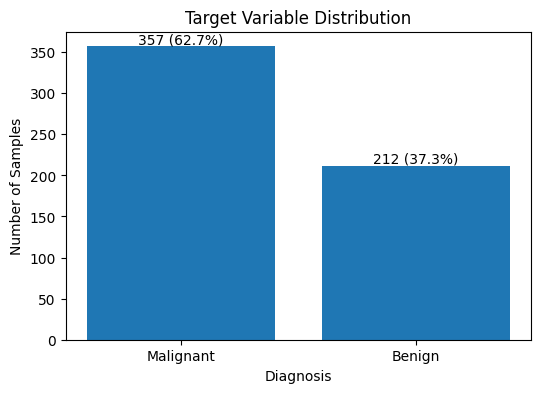

In [ ]:
import matplotlib.pyplot as plt

# Get counts
class_counts = df['target'].value_counts()

# Rename for clarity
class_counts.index = ['Malignant', 'Benign']

# Calculate percentages
total = class_counts.sum()
percentages = (class_counts / total) * 100

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values)

# Add labels on top
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{class_counts[i]} ({percentages[i]:.1f}%)",
        ha='center',
        va='bottom'
    )

# Labels + title
plt.xlabel('Diagnosis')
plt.ylabel('Number of Samples')
plt.title('Target Variable Distribution')

plt.show()

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
mean_radius,float64
mean_texture,float64
mean_perimeter,float64
mean_area,float64
mean_smoothness,float64
mean_compactness,float64
mean_concavity,float64
mean_concave_points,float64
mean_symmetry,float64
mean_fractal_dimension,float64


In [ ]:
# Drop target column (we only want features)
features = df.drop(columns=['target'])

# Summary statistics
summary_stats = features.describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave_points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
features = df.drop(columns=['target'])

# Calculate range
range_values = features.max() - features.min()

# Put into a clean table
range_df = pd.DataFrame({
    'Min': features.min(),
    'Max': features.max(),
    'Range': range_values
})

range_df

,Min,Max,Range
mean_radius,6.981000,28.11000,21.129000
mean_texture,9.710000,39.28000,29.570000
mean_perimeter,43.790000,188.50000,144.710000
mean_area,143.500000,2501.00000,2357.500000
mean_smoothness,0.052630,0.16340,0.110770
mean_compactness,0.019380,0.34540,0.326020
mean_concavity,0.000000,0.42680,0.426800
mean_concave_points,0.000000,0.20120,0.201200
mean_symmetry,0.106000,0.30400,0.198000
mean_fractal_dimension,0.049960,0.09744,0.047480


In [ ]:
# Drop target column
features = df.drop(columns=['target'])

# Calculate variance and sort
variance_sorted = features.var().sort_values(ascending=False)

variance_sorted

,0
worst_area,324167.385102
mean_area,123843.554318
area_error,2069.431583
worst_perimeter,1129.130847
mean_perimeter,590.440480
worst_texture,37.776483
worst_radius,23.360224
mean_texture,18.498909
mean_radius,12.418920
perimeter_error,4.087896


/tmp/ipykernel_5603/189219451.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{class_counts[i]} ({percentages[i]:.1f}%)",


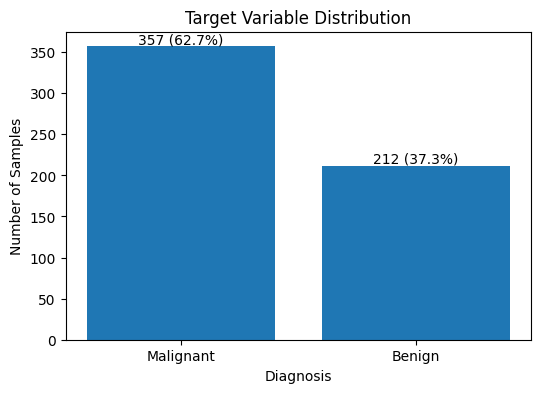

In [ ]:
import matplotlib.pyplot as plt

# Get counts
class_counts = df['target'].value_counts()

# Rename for clarity
class_counts.index = ['Malignant', 'Benign']

# Calculate percentages
total = class_counts.sum()
percentages = (class_counts / total) * 100

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values)

# Add labels on top
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{class_counts[i]} ({percentages[i]:.1f}%)",
        ha='center',
        va='bottom'
    )

# Labels + title
plt.xlabel('Diagnosis')
plt.ylabel('Number of Samples')
plt.title('Target Variable Distribution')

plt.show()

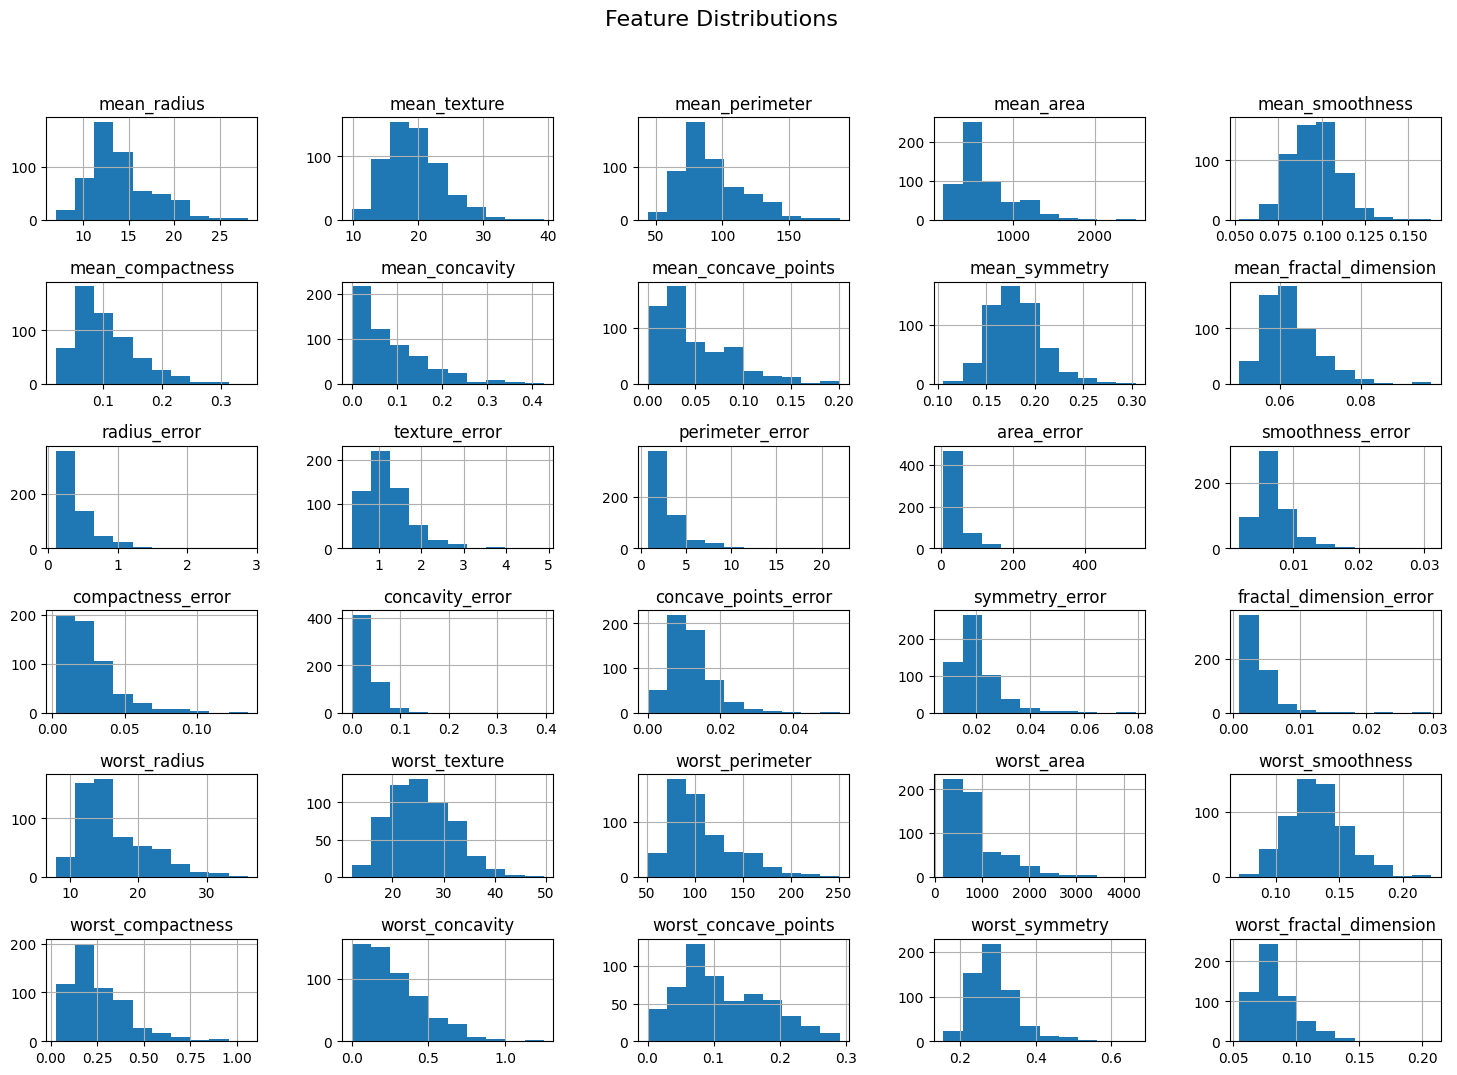

In [ ]:
import matplotlib.pyplot as plt

features = df.drop(columns=['target'])

# Bigger figure + spacing
fig = features.hist(figsize=(18, 12))

# Adjust spacing between plots
plt.subplots_adjust(hspace=0.6, wspace=0.4)

# Add main title with spacing
plt.suptitle("Feature Distributions", fontsize=16, y=0.97)

plt.show()

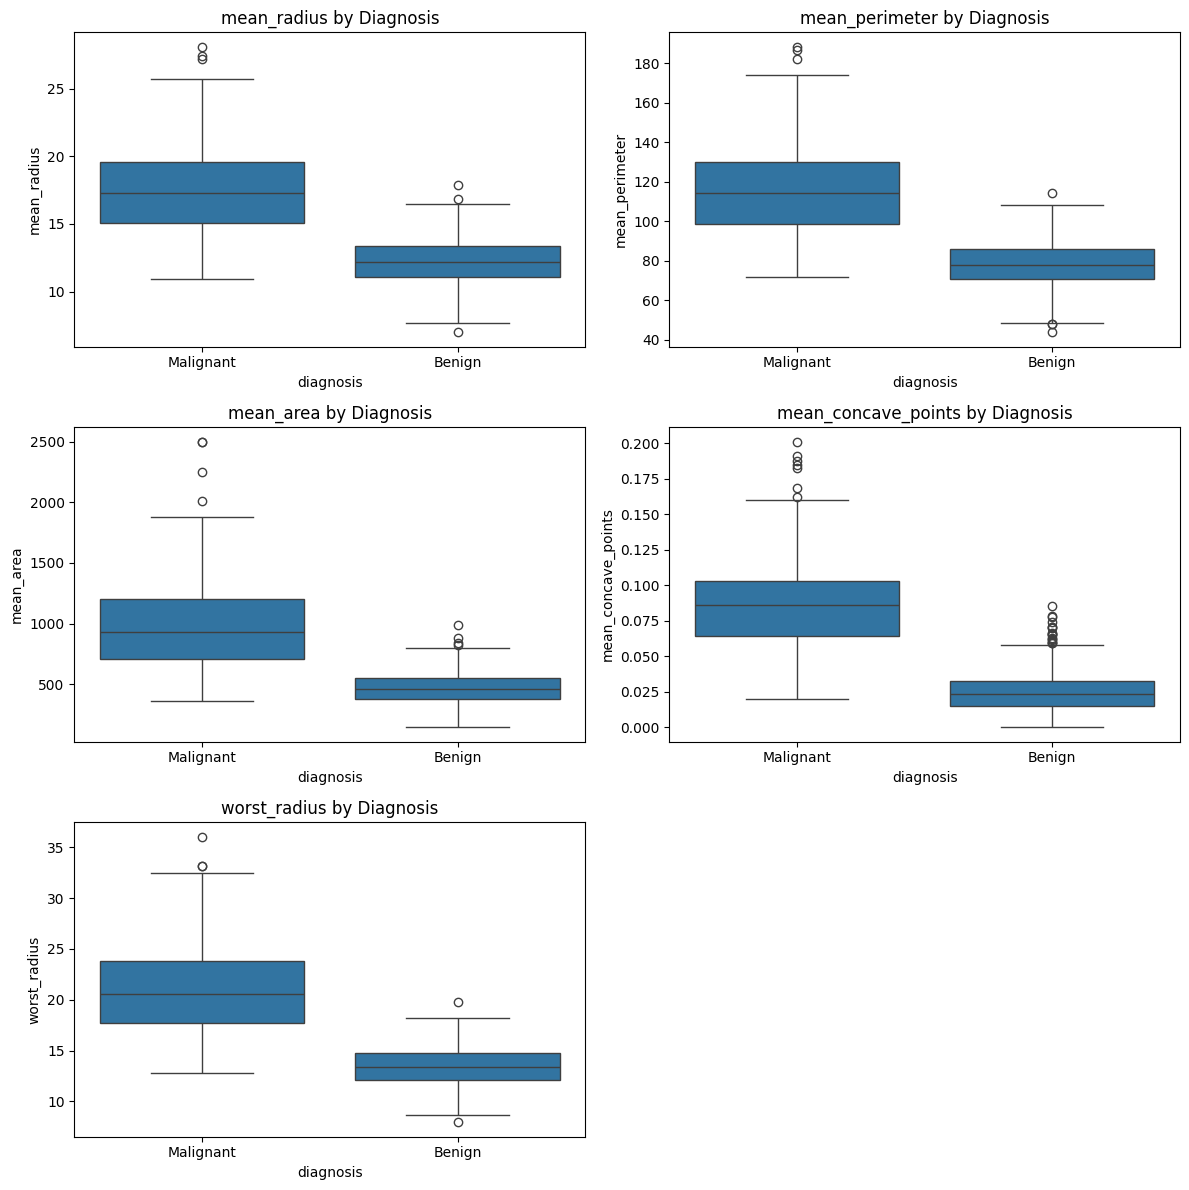

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add readable labels
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

selected_features = [
    'mean_radius',
    'mean_perimeter',
    'mean_area',
    'mean_concave_points',
    'worst_radius'
]

# Create subplot grid (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes = axes.flatten()  # makes indexing easier

# Plot each feature
for i, feature in enumerate(selected_features):
    sns.boxplot(x='diagnosis', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f"{feature} by Diagnosis")

# Remove the empty subplot (last one)
fig.delaxes(axes[-1])

# Adjust layout
plt.tight_layout()
plt.show()

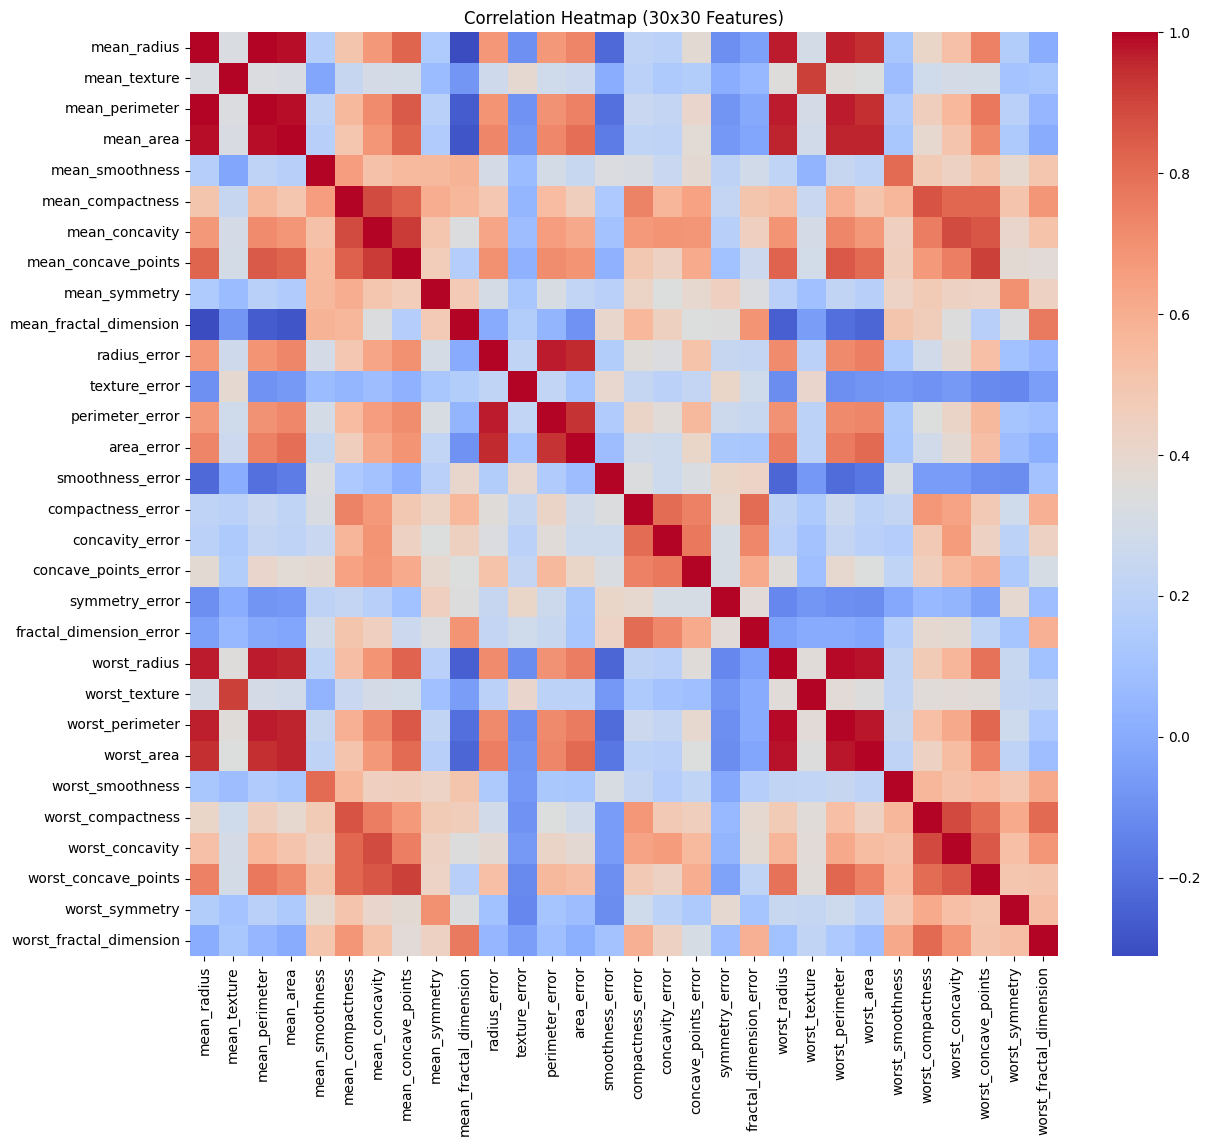

In [ ]:
plt.figure(figsize=(14, 12))

correlation_matrix = df.drop(columns=['target', 'diagnosis']).corr()

sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap (30x30 Features)")
plt.show()

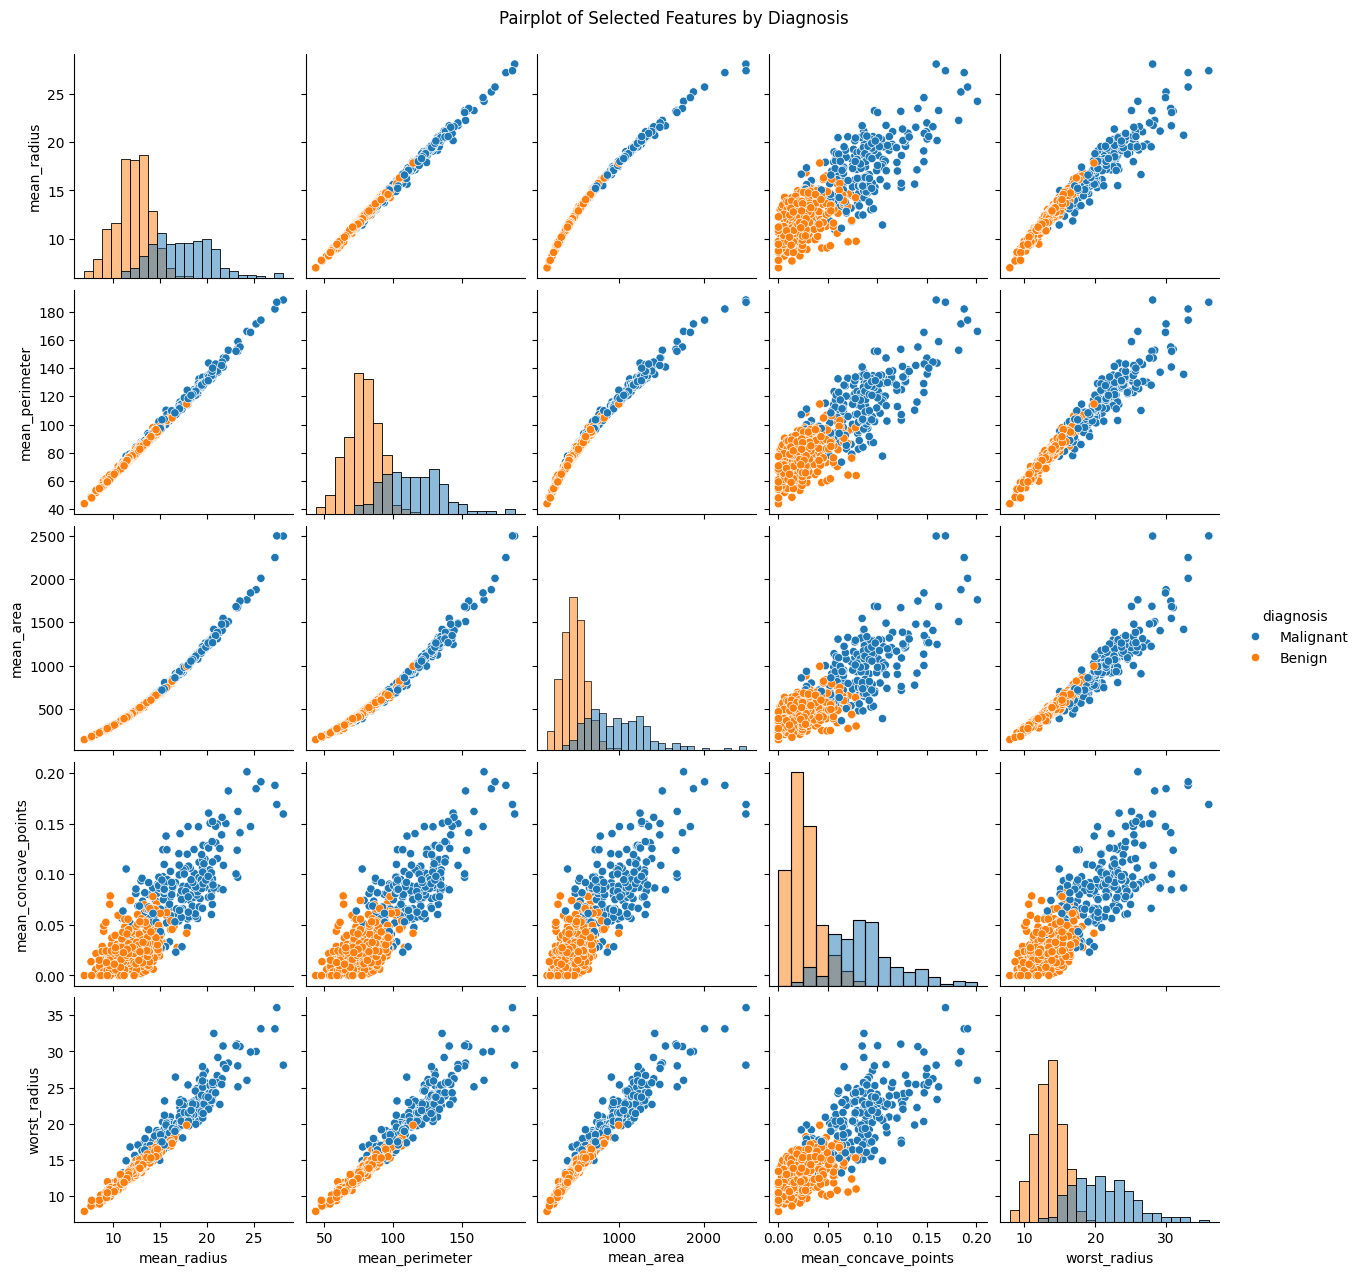

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure diagnosis column exists
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

selected_features = [
    'mean_radius',
    'mean_perimeter',
    'mean_area',
    'mean_concave_points',
    'worst_radius'
]

# Pairplot
sns.pairplot(
    df[selected_features + ['diagnosis']],
    hue='diagnosis',
    diag_kind='hist'
)

plt.suptitle("Pairplot of Selected Features by Diagnosis", y=1.02)
plt.show()

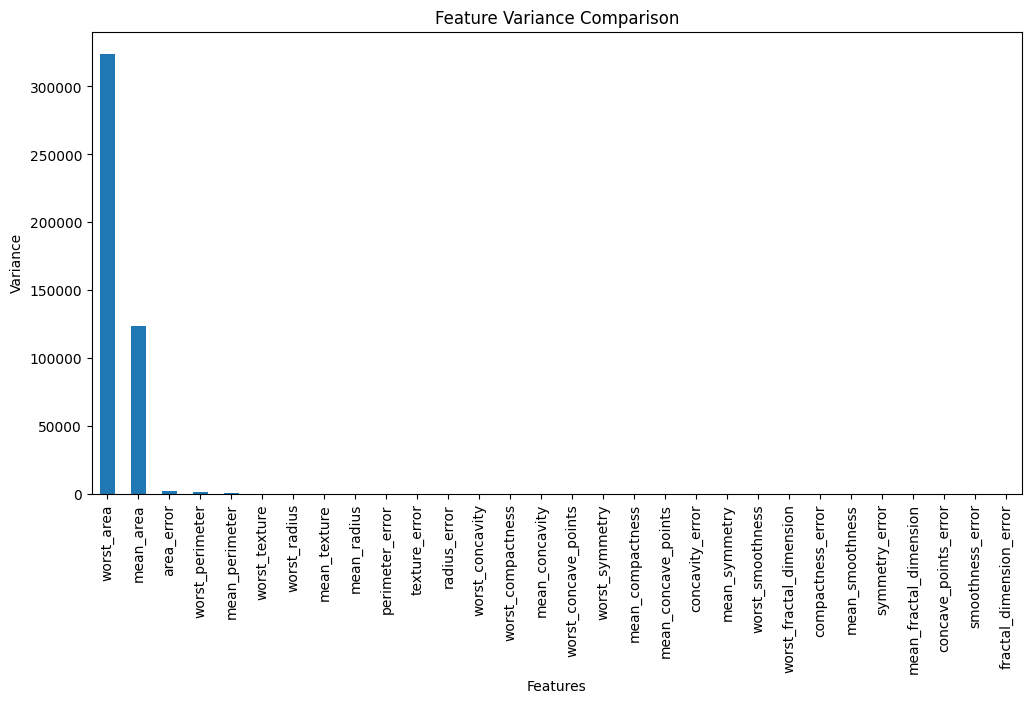

In [ ]:
import matplotlib.pyplot as plt

# Calculate variance (USE ORIGINAL DATA)
variance = df.drop(columns=['target', 'diagnosis']).var()

# Sort from highest → lowest
variance_sorted = variance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
variance_sorted.plot(kind='bar')

plt.title("Feature Variance Comparison")
plt.xlabel("Features")
plt.ylabel("Variance")
plt.xticks(rotation=90)

plt.show()

In [ ]:
features = df.drop(columns=['target', 'diagnosis'])

# Coefficient of Variation
cv = (features.std() / features.mean()).sort_values(ascending=False)

cv

,0
area_error,1.127771
concavity_error,0.946458
mean_concavity,0.897753
mean_concave_points,0.793204
worst_concavity,0.766470
perimeter_error,0.705448
compactness_error,0.702884
fractal_dimension_error,0.697270
radius_error,0.684432
worst_area,0.646568


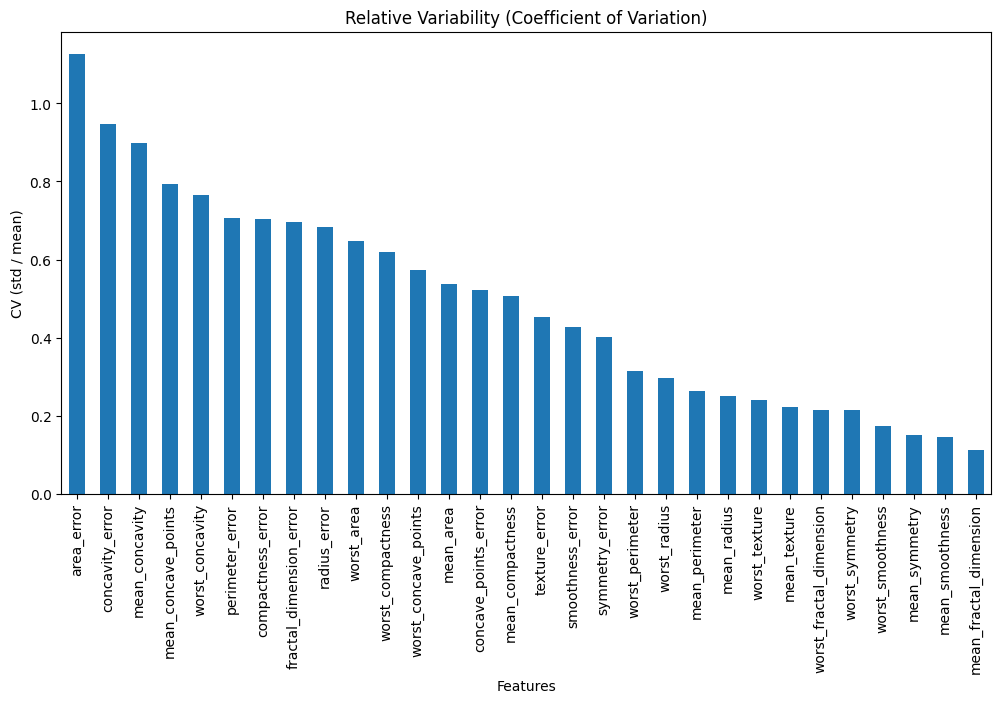

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
cv.plot(kind='bar')

plt.title("Relative Variability (Coefficient of Variation)")
plt.xlabel("Features")
plt.ylabel("CV (std / mean)")
plt.xticks(rotation=90)

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

features = df.drop(columns=['target', 'diagnosis'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

scaled_df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
print("BEFORE SCALING:")
print(features[['mean_area', 'mean_smoothness']].head())

print("\nAFTER SCALING:")
print(scaled_df[['mean_area', 'mean_smoothness']].head())

BEFORE SCALING:
   mean_area  mean_smoothness
0     1001.0          0.11840
1     1326.0          0.08474
2     1203.0          0.10960
3      386.1          0.14250
4     1297.0          0.10030

AFTER SCALING:
   mean_area  mean_smoothness
0   0.984375         1.568466
1   1.908708        -0.826962
2   1.558884         0.942210
3  -0.764464         3.283553
4   1.826229         0.280372


In [ ]:
print("Mean after scaling:")
print(scaled_df.mean())

print("\nStd after scaling:")
print(scaled_df.std())

Mean after scaling:
mean_radius               -3.162867e-15
mean_texture              -6.530609e-15
mean_perimeter            -7.078891e-16
mean_area                 -8.799835e-16
mean_smoothness            6.132177e-15
mean_compactness          -1.120369e-15
mean_concavity            -4.421380e-16
mean_concave_points        9.732500e-16
mean_symmetry             -1.971670e-15
mean_fractal_dimension    -1.453631e-15
radius_error              -9.076415e-16
texture_error             -8.853492e-16
perimeter_error            1.773674e-15
area_error                -8.291551e-16
smoothness_error          -7.541809e-16
compactness_error         -3.921877e-16
concavity_error            7.917900e-16
concave_points_error      -2.739461e-16
symmetry_error            -3.108234e-16
fractal_dimension_error   -3.366766e-16
worst_radius              -2.333224e-15
worst_texture              1.763674e-15
worst_perimeter           -1.198026e-15
worst_area                 5.049661e-16
worst_smoothness    

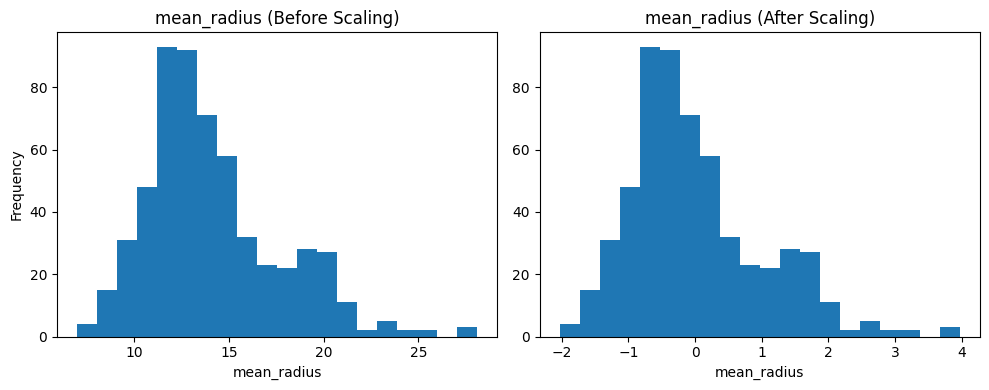

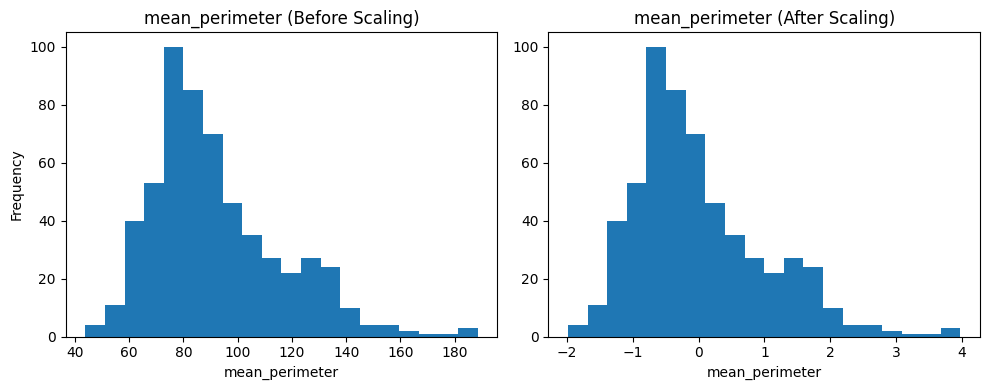

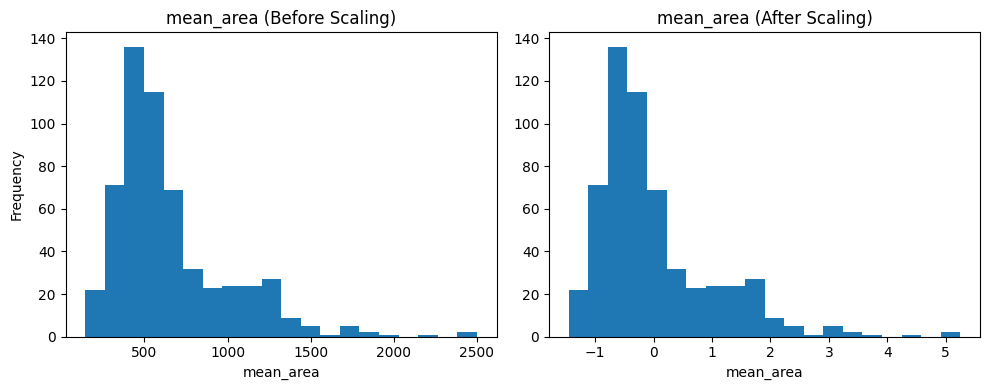

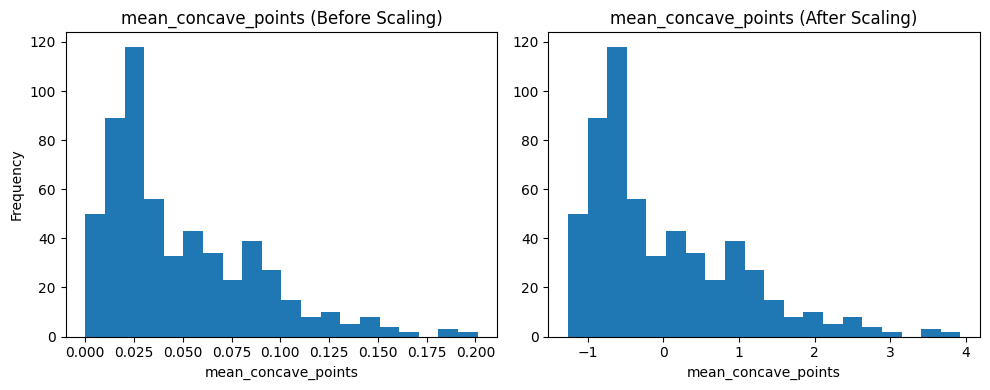

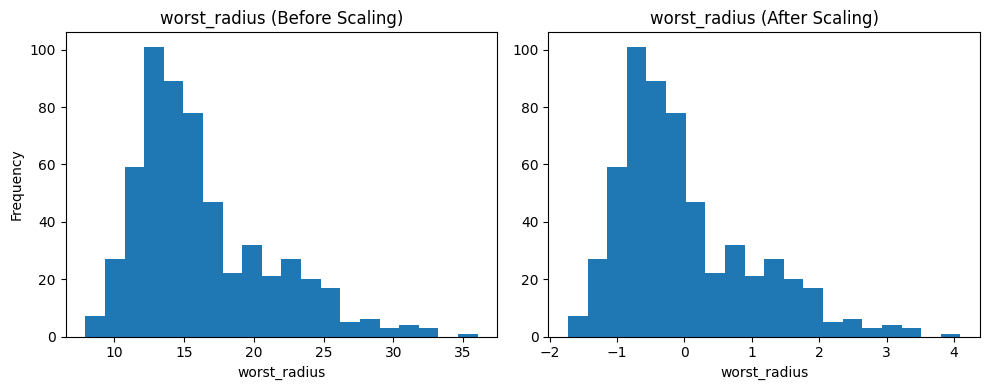

In [ ]:
import matplotlib.pyplot as plt

selected_features = [
    'mean_radius',
    'mean_perimeter',
    'mean_area',
    'mean_concave_points',
    'worst_radius'
]

# Loop through each feature
for feature in selected_features:
    plt.figure(figsize=(10,4))

    # BEFORE scaling
    plt.subplot(1,2,1)
    plt.hist(df[feature], bins=20)
    plt.title(f"{feature} (Before Scaling)")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    # AFTER scaling
    plt.subplot(1,2,2)
    plt.hist(scaled_df[feature], bins=20)
    plt.title(f"{feature} (After Scaling)")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = scaled_df   # use scaled data for modeling
y = df['target']

# 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 455
Testing set size: 114


In [ ]:
print("\nOriginal distribution:")
print(y.value_counts(normalize=True))

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Original distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Train distribution:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test distribution:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


PCA Usage

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Fit PCA on TRAINING data (important)
pca = PCA()
pca.fit(X_train)


PCA()

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

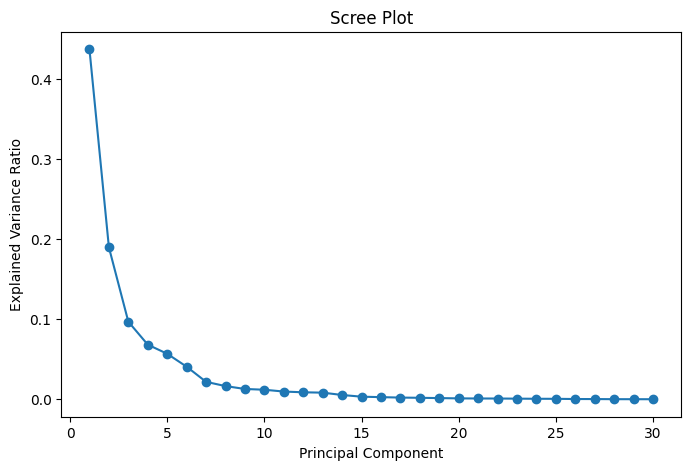

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

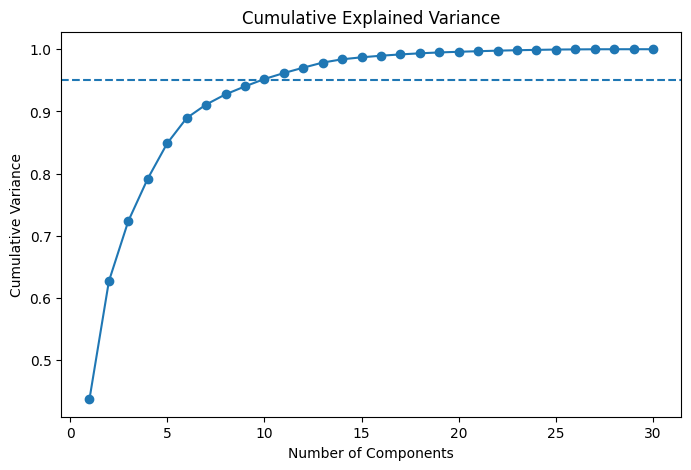

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, linestyle='--')  # 95% threshold
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Fit PCA on training data
pca = PCA()
pca.fit(X_train)

# Get explained variance for each component
explained_variance = pca.explained_variance_ratio_

# Get cumulative variance
cumulative_variance = np.cumsum(explained_variance)

# Create table
pca_variance_table = pd.DataFrame({
    "Component (k)": range(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": cumulative_variance
})

# Display table
pca_variance_table

,Component (k),Explained Variance Ratio,Cumulative Variance
0,1,0.437149,0.437149
1,2,0.189754,0.626903
2,3,0.096836,0.723739
3,4,0.068162,0.791901
4,5,0.056760,0.848661
5,6,0.040629,0.889290
6,7,0.021721,0.911010
7,8,0.016400,0.927410
8,9,0.012809,0.940219
9,10,0.011852,0.952071


In [ ]:
optimal_k = np.argmax(cumulative_variance >= 0.95) + 1
print("Optimal number of components (95% variance):", optimal_k)

Optimal number of components (95% variance): 10


In [ ]:
for k in [2, 5, 10, 15]:
    pca_temp = PCA(n_components=k)
    pca_temp.fit(X_train)

    total_var = pca_temp.explained_variance_ratio_.sum()
    print(f"k = {k}: Total Variance = {total_var:.4f}")

k = 2: Total Variance = 0.6269
k = 5: Total Variance = 0.8487
k = 10: Total Variance = 0.9521
k = 15: Total Variance = 0.9870


In [ ]:
pca_optimal = PCA(n_components=10)
pca_optimal.fit(X_train)

PCA(n_components=10)

In [ ]:
X_train_pca = pca_optimal.transform(X_train)
X_test_pca = pca_optimal.transform(X_test)

In [ ]:
explained_variance = pca_optimal.explained_variance_ratio_

print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])

Variance explained by PC1: 0.43714936414484745
Variance explained by PC2: 0.1897535985123369


In [ ]:
total_variance = explained_variance.sum()
print("Total variance explained by 10 components:", total_variance)

Total variance explained by 10 components: 0.9520709250260171


In [ ]:
# Use existing PCA results (DO NOT refit)

pca_vis_df = pd.DataFrame(
    X_train_pca[:, :3],
    columns=['PC1', 'PC2', 'PC3']
)

pca_vis_df['target'] = y_train.values
pca_vis_df['diagnosis'] = pca_vis_df['target'].map({0: 'Malignant', 1: 'Benign'})

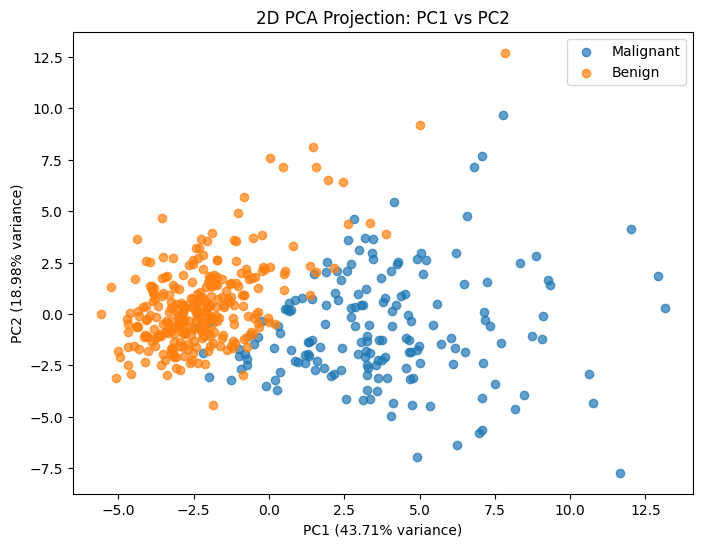

In [ ]:
explained = pca_optimal.explained_variance_ratio_

plt.figure(figsize=(8, 6))

for diagnosis in ['Malignant', 'Benign']:
    subset = pca_vis_df[pca_vis_df['diagnosis'] == diagnosis]
    plt.scatter(subset['PC1'], subset['PC2'], label=diagnosis, alpha=0.7)

plt.xlabel(f"PC1 ({explained[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.2f}% variance)")
plt.title("2D PCA Projection: PC1 vs PC2")
plt.legend()

plt.show()

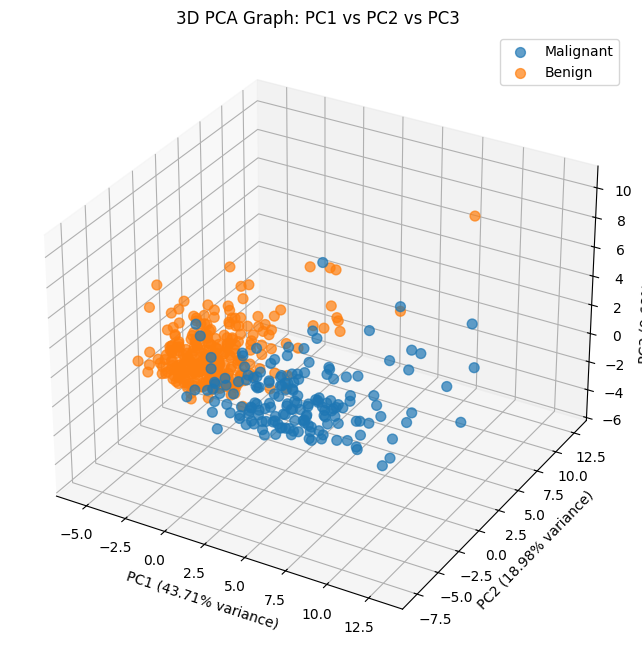

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for diagnosis in ['Malignant', 'Benign']:
    subset = pca_vis_df[pca_vis_df['diagnosis'] == diagnosis]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        label=diagnosis,
        alpha=0.7,
        s=50
    )

ax.set_xlabel(f"PC1 ({explained[0]*100:.2f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.2f}% variance)")
ax.set_zlabel(f"PC3 ({explained[2]*100:.2f}% variance)")
ax.set_title("3D PCA Graph: PC1 vs PC2 vs PC3")
ax.legend()

plt.show()

In [ ]:
# Get loadings (rows = PCs, columns = features)
loadings = pd.DataFrame(
    pca_optimal.components_,
    columns=X_train.columns,
    index=[f'PC{i+1}' for i in range(pca_optimal.n_components_)]
)

loadings

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
PC1,0.209553,0.096970,0.218931,0.208837,0.144305,0.248621,0.265735,0.260314,0.152274,0.080586,...,0.216850,0.098464,0.226259,0.210008,0.129787,0.218599,0.241708,0.253625,0.140402,0.143141
PC2,-0.246822,-0.072770,-0.228881,-0.237899,0.152118,0.127102,0.048790,-0.054708,0.178100,0.360062,...,-0.232857,-0.057794,-0.214070,-0.225822,0.142935,0.122586,0.083802,-0.030365,0.131186,0.261007
PC3,0.015913,0.089428,0.013748,0.046915,-0.113359,-0.073177,0.002383,-0.023734,-0.063553,-0.038241,...,-0.027994,-0.015791,-0.030384,-0.000839,-0.262173,-0.237883,-0.176754,-0.167914,-0.276416,-0.242958
PC4,-0.045646,0.604623,-0.046306,-0.057512,-0.139296,-0.025989,-0.021822,-0.067657,-0.067747,-0.036556,...,-0.016259,0.631241,-0.016406,-0.022925,-0.007942,0.099858,0.081070,-0.000398,0.032685,0.097709
PC5,0.034663,-0.043486,0.033052,0.010391,-0.309194,0.000809,0.080756,-0.035975,-0.333511,-0.033258,...,-0.000187,-0.083090,0.007271,-0.017840,-0.265374,0.090878,0.168822,0.045926,-0.308263,0.084011
PC6,0.020892,-0.020629,0.018255,-0.009714,-0.309906,-0.018699,-0.019809,-0.064692,0.297865,-0.123454,...,-0.002713,-0.049652,0.006429,-0.034279,-0.419629,0.048388,0.026647,-0.024886,0.449317,-0.073779
PC7,-0.070147,-0.030476,-0.062044,-0.017194,-0.100802,0.074168,-0.112405,-0.097818,-0.078911,0.331695,...,0.014311,-0.019383,0.019936,0.068543,-0.151661,0.141246,-0.103395,-0.163134,-0.080978,0.389636
PC8,0.044541,0.153488,0.032499,0.075870,-0.275234,-0.098814,-0.124602,-0.146395,-0.279049,-0.113469,...,0.072864,0.031542,0.057913,0.099704,0.115916,0.116663,-0.007868,-0.072599,0.215271,0.105124
PC9,0.190784,-0.211808,0.198501,0.149237,0.027026,0.206470,0.021159,0.140852,-0.241621,0.035992,...,0.071103,-0.126171,0.083226,0.036917,-0.130616,0.167335,-0.058617,0.010587,-0.108724,0.053363
PC10,0.139364,0.158503,0.130866,0.124133,-0.040650,0.013667,-0.045079,0.065237,0.572175,0.096166,...,0.098505,0.006062,0.067586,0.099751,-0.136241,-0.215878,-0.266880,-0.105194,-0.026027,-0.010265


In [ ]:
loadings.loc['PC1'].sort_values(ascending=False).head(5)


,PC1
mean_concavity,0.265735
mean_concave_points,0.260314
worst_concave_points,0.253625
mean_compactness,0.248621
worst_concavity,0.241708


In [ ]:
loadings.loc['PC2'].sort_values(ascending=False).head(5)

,PC2
mean_fractal_dimension,0.360062
fractal_dimension_error,0.291664
worst_fractal_dimension,0.261007
compactness_error,0.234861
smoothness_error,0.212409


In [ ]:
for k in [2, 5, 10, 15]:
    pca_temp = PCA(n_components=k)
    pca_temp.fit(X_train)

    total_var = pca_temp.explained_variance_ratio_.sum()
    print(f"k = {k}: Total Variance = {total_var:.4f}")

k = 2: Total Variance = 0.6269
k = 5: Total Variance = 0.8487
k = 10: Total Variance = 0.9521
k = 15: Total Variance = 0.9870


LDA Usage

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA (max 1 component for binary classification)
lda = LinearDiscriminantAnalysis(n_components=1)

# Fit on training data
lda.fit(X_train, y_train)

# Transform data
X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

In [ ]:
print("Explained variance ratio (LD1):", lda.explained_variance_ratio_)

Explained variance ratio (LD1): [1.]


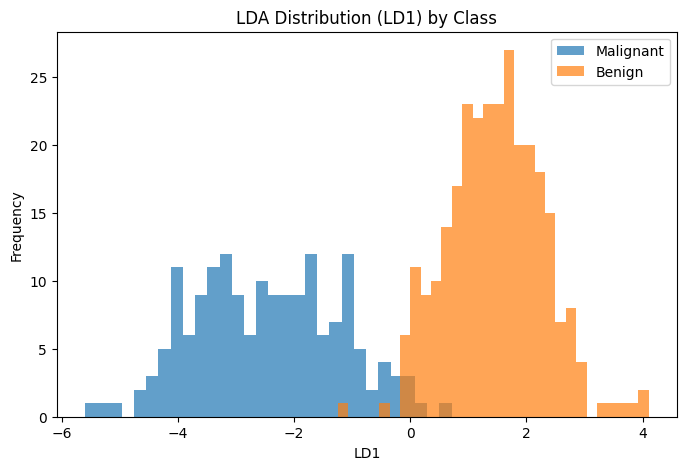

In [ ]:
import matplotlib.pyplot as plt

# Separate classes
malignant = X_train_lda[y_train == 0]
benign = X_train_lda[y_train == 1]

plt.figure(figsize=(8,5))

plt.hist(malignant, bins=30, alpha=0.7, label='Malignant')
plt.hist(benign, bins=30, alpha=0.7, label='Benign')

plt.xlabel("LD1")
plt.ylabel("Frequency")
plt.title("LDA Distribution (LD1) by Class")
plt.legend()

plt.show()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA (1 component for binary classification)
lda = LinearDiscriminantAnalysis(n_components=1)

# Fit model
lda.fit(X_train, y_train)

# Get explained variance ratio
lda_variance = lda.explained_variance_ratio_

print("Explained Variance Ratio (LD1):", lda_variance)

Explained Variance Ratio (LD1): [1.]


In [ ]:
# Get coefficients
lda_coefficients = pd.Series(
    lda.coef_[0],
    index=X_train.columns
)

# Top 5 features (by magnitude)
top_features = lda_coefficients.abs().sort_values(ascending=False)

top_features

,0
worst_radius,16.827296
mean_radius,13.506094
mean_perimeter,12.007861
worst_area,11.272715
mean_compactness,5.331798
radius_error,3.146879
concavity_error,2.542580
perimeter_error,2.098719
worst_concavity,2.077595
mean_concavity,2.071314


In [ ]:
lda_coefficients.sort_values(ascending=False)

,0
mean_radius,13.506094
worst_area,11.272715
mean_compactness,5.331798
concavity_error,2.542580
perimeter_error,2.098719
worst_perimeter,0.722891
fractal_dimension_error,0.531564
symmetry_error,0.136479
area_error,0.097657
worst_smoothness,0.051618


Comparision Between PCA and LDA

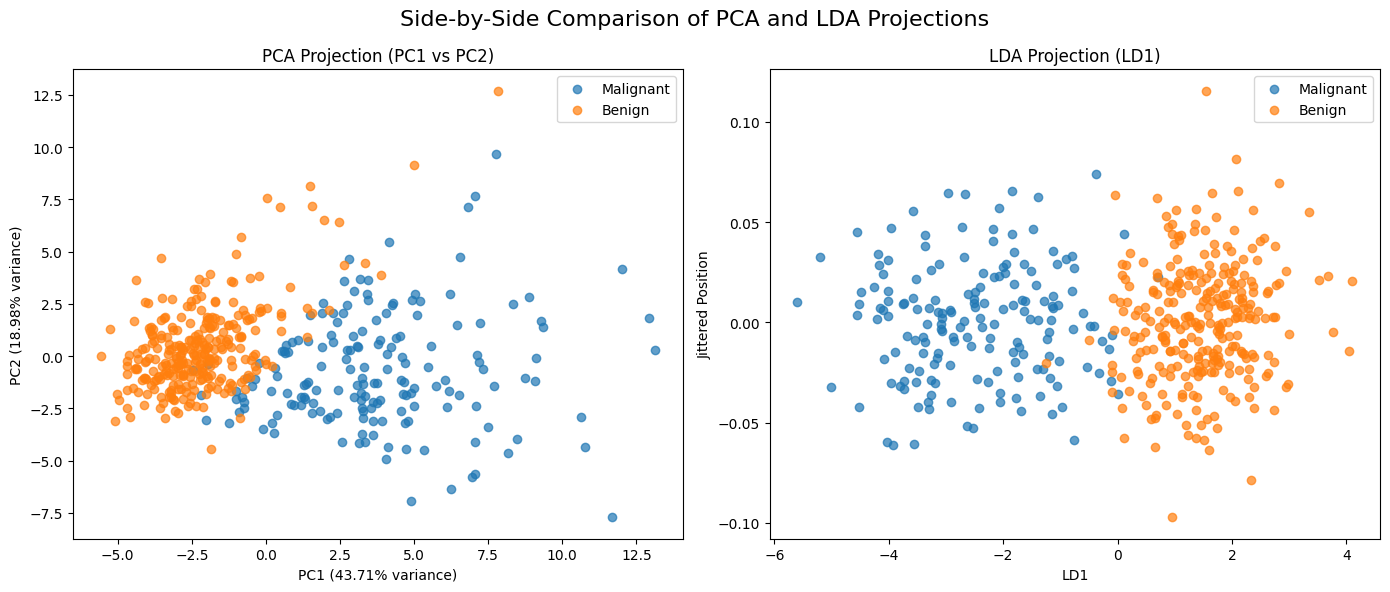

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# PCA data for plotting
# -----------------------------
pca_compare_df = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'target': y_train.values
})
pca_compare_df['diagnosis'] = pca_compare_df['target'].map({0: 'Malignant', 1: 'Benign'})

# -----------------------------
# LDA data for plotting
# -----------------------------
lda_compare_df = pd.DataFrame({
    'LD1': X_train_lda[:, 0],
    'target': y_train.values
})
lda_compare_df['diagnosis'] = lda_compare_df['target'].map({0: 'Malignant', 1: 'Benign'})

# Small jitter so LDA points don't overlap too much
np.random.seed(42)
lda_compare_df['y_jitter'] = np.random.normal(0, 0.03, size=len(lda_compare_df))

# Explained variance for PCA axis labels
pca_explained = pca_optimal.explained_variance_ratio_

# -----------------------------
# Side-by-side plots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA plot
for diagnosis in ['Malignant', 'Benign']:
    subset = pca_compare_df[pca_compare_df['diagnosis'] == diagnosis]
    axes[0].scatter(subset['PC1'], subset['PC2'], label=diagnosis, alpha=0.7)

axes[0].set_xlabel(f"PC1 ({pca_explained[0]*100:.2f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_explained[1]*100:.2f}% variance)")
axes[0].set_title("PCA Projection (PC1 vs PC2)")
axes[0].legend()

# LDA plot
for diagnosis in ['Malignant', 'Benign']:
    subset = lda_compare_df[lda_compare_df['diagnosis'] == diagnosis]
    axes[1].scatter(subset['LD1'], subset['y_jitter'], label=diagnosis, alpha=0.7)

axes[1].set_xlabel("LD1")
axes[1].set_ylabel("Jittered Position")
axes[1].set_title("LDA Projection (LD1)")
axes[1].legend()

plt.suptitle("Side-by-Side Comparison of PCA and LDA Projections", fontsize=16)
plt.tight_layout()
plt.show()

<Axes: xlabel='LD1', ylabel='diagnosis'>

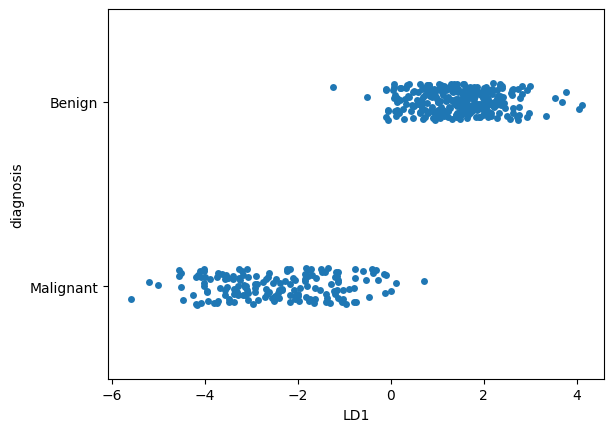

In [ ]:
sns.stripplot(x='LD1', y='diagnosis', data=lda_compare_df)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Model for original data
model_original = LogisticRegression(max_iter=1000)
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)

# Model for PCA data
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)

# Model for LDA data
model_lda = LogisticRegression(max_iter=1000)
model_lda.fit(X_train_lda, y_train)
y_pred_lda = model_lda.predict(X_test_lda)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

In [ ]:
results = pd.DataFrame([
    ["Original (30 features)", *get_metrics(y_test, y_pred_original).values()],
    ["PCA (10 components)", *get_metrics(y_test, y_pred_pca).values()],
    ["LDA (1 component)", *get_metrics(y_test, y_pred_lda).values()]
],
columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Original (30 features),0.9825,0.9861,0.9861,0.9861
1,PCA (10 components),0.9737,0.9859,0.9722,0.9790
2,LDA (1 component),0.9737,0.9726,0.9861,0.9793
